# SVM

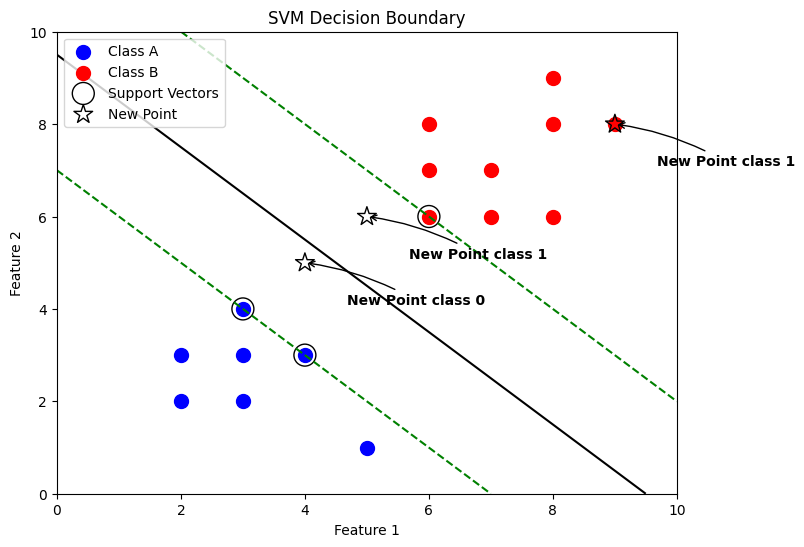

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

x = np.array([
    [5,1],[2,2],[2,3],[3,2],[3,3],[4,3],[3,4],[6,6],[6,7],[7,6],[7,7],[8,6], [6,8], [8,8], [9,8], [8,9]
])
y = np.array([0,0,0,0,0,0,0,1,1,1,1,1,1, 1,1,1])
model = SVC(kernel='linear', C=1.0)
model.fit(x,y)

x_min, x_max = 0, 10
y_min, y_max = 0, 10
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
    )

grid = np.c_[xx.ravel(), yy.ravel()]
z = model.decision_function(grid).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.scatter(x[y==0,0], x[y==0,1], color='blue', s=100, label='Class A')
plt.scatter(x[y==1,0], x[y==1,1], color='red', s=100, label='Class B')
plt.contour(xx, yy, z, colors=['green', 'black', 'green'], levels=[-1, 0, 1], linestyles=['--', '-', '--'])
sv = model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=250, facecolor='none', edgecolors="black", label='Support Vectors')

new_points = np.array([[4,5], [5,6], [9,8]])
for i in range(len(new_points)):
    new_point = new_points[i].reshape(1, -1)
    prediction = model.predict(new_point)[0]

    lbl = 'New Point' if i == 0 else ""
    plt.scatter(new_point[:, 0], new_point[:, 1], s=200, facecolor='none', edgecolors="black", label=lbl, marker='*')
    plt.annotate(f'New Point class {prediction}',
                xy=(new_point[0, 0], new_point[0, 1]),
                xytext=(30, -30),
                textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="black",  connectionstyle="arc3,rad=0.1"),
                fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary')
plt.legend()

plt.show()